# **Analisis Pengangguran dan Perubahan Dunia Kerja di Indonesia Berbasis Data Time Series**

**Nama:** Suci Wulandari<br>
**NIM:** E1E124052<br>
**E-Mail:** pramitasuci632@gmail.com

# **Menentukan Pertanyaan Bisnis**

1. Bagaimana perkembangan jumlah tenaga kerja di Indonesia berdasarkan lapangan usaha dari tahun 2021–2025?

2. Apakah tingkat pengangguran memiliki hubungan dengan jumlah tenaga kerja berdasarkan lapangan usaha di Indonesia?

3. Apakah konsentrasi tenaga kerja antarprovinsi memiliki hubungan dengan jumlah tenaga kerja berdasarkan lapangan usaha di Indonesia?

4. Dapatkah tingkat pengangguran pada periode berikutnya diprediksi berdasarkan data historis tingkat pengangguran di Indonesia?

# **Import Semua Packages/Library.**

In [2]:
%pip install sqlalchemy pymysql

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Import library yang digunakan

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sqlalchemy import create_engine

# **Data Wrangling**

### **Gathering Data**

1. Koneksi Ke MySQL

In [4]:
# Import library untuk koneksi MySQL
from sqlalchemy import create_engine

# Koneksi ke database MySQL
engine = create_engine(
    "mysql+pymysql://root:@localhost:3306/data_science_2"
)

print("Koneksi ke MySQL berhasil!")

Koneksi ke MySQL berhasil!


2. Ambil Tabel 1

In [5]:
# Mengambil data tenaga kerja dari MySQL

df_pekerja = pd.read_sql(
    "SELECT * FROM produksi_tenaga_kerja",
    engine
)

df_pekerja.head()

,id,tahun,periode,lapangan_usaha,jumlah_pekerja
0,1,2025,Agustus,"Administrasi Pemerintahan, Pertahanan, dan Jam...",5130470
1,2,2025,Agustus,Industri Pengolahan,20308685
2,3,2025,Agustus,Informasi dan Komunikasi,1064357
3,4,2025,Agustus,Jasa Kesehatan dan Kegiatan Sosial,2458567
4,5,2025,Agustus,Jasa Keuangan dan Asuransi,1650077


3. Ambil Tabel 2

In [6]:
# Mengambil data tingkat pengangguran dari MySQL

df_pengangguran = pd.read_sql(
    "SELECT * FROM tingkat_pengangguran",
    engine
)

df_pengangguran.head()

,id,tahun,periode,wilayah,tingkat_pengangguran
0,1,2025,Agustus,ACEH,5.64
1,2,2025,Agustus,BALI,1.49
2,3,2025,Agustus,BANTEN,6.69
3,4,2025,Agustus,BENGKULU,3.41
4,5,2025,Agustus,DI YOGYAKARTA,3.46


4. Ambil Tabel 3

In [7]:
# Mengambil data tenaga kerja berdasarkan provinsi dan lapangan usaha

df_pekerja_provinsi = pd.read_sql(
    "SELECT * FROM pekerja_provinsi",
    engine
)

df_pekerja_provinsi.head()

,id,tahun,periode,wilayah,lapangan_usaha,jumlah_pekerja
0,1,2021,Agustus,ACEH,"A Pertanian, Kehutanan dan Perikanan",853153
1,2,2021,Agustus,ACEH,B Pertambangan dan Penggalian,13773
2,3,2021,Agustus,ACEH,C Industri Pengolahan,197345
3,4,2021,Agustus,ACEH,D Pengadaan Listrik dan Gas,6740
4,5,2021,Agustus,ACEH,"E Pengadaan Air, Pengelolaan Sampah, Limbah da...",4557


#### **Insight Gathering Data**

- Data tenaga kerja menurut lapangan usaha berhasil dikumpulkan dari tabel `produksi_tenaga_kerja`.
- Data tingkat pengangguran berhasil dikumpulkan dari tabel `tingkat_pengangguran`.
- Data tenaga kerja berdasarkan provinsi dan lapangan usaha berhasil dikumpulkan dari tabel `pekerja_provinsi`.
- Ketiga dataset memiliki informasi periode waktu sehingga dapat digunakan untuk analisis perubahan dari tahun 2021–2025.
- Data tenaga kerja berdasarkan provinsi dan lapangan usaha dapat digunakan untuk melihat distribusi tenaga kerja antarwilayah.

### **Assessing Data**

Assessing Tabel 1: Tenaga Kerja Menurut Lapangan Usaha

In [8]:
# Mengecek jumlah baris dan kolom Tabel 1

print("Jumlah baris dan kolom:", df_pekerja.shape)

Jumlah baris dan kolom: (360, 5)


In [9]:
# Mengecek tipe data setiap kolom

df_pekerja.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              360 non-null    int64 
 1   tahun           360 non-null    int64 
 2   periode         360 non-null    object
 3   lapangan_usaha  360 non-null    object
 4   jumlah_pekerja  360 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 14.2+ KB


In [10]:
# Mengecek missing value pada Tabel 1

df_pekerja.isnull().sum()

id                0
tahun             0
periode           0
lapangan_usaha    0
jumlah_pekerja    0
dtype: int64

In [11]:
# Mengecek jumlah data duplikat pada Tabel 1

df_pekerja.duplicated().sum()

np.int64(0)

In [12]:
# Mengecek nilai unik pada beberapa kolom Tabel 1

print("Tahun:")
print(df_pekerja["tahun"].unique())

print("\nPeriode:")
print(df_pekerja["periode"].unique())

print("\nLapangan Usaha:")
print(df_pekerja["lapangan_usaha"].unique())

Tahun:
[2025 2021 2022 2023 2024]

Periode:
['Agustus' 'Februari']

Lapangan Usaha:
['Administrasi Pemerintahan, Pertahanan, dan Jaminan Sosial Wajib'
 'Industri Pengolahan' 'Informasi dan Komunikasi'
 'Jasa Kesehatan dan Kegiatan Sosial' 'Jasa Keuangan dan Asuransi'
 'Jasa Lainnya' 'Jasa Pendidikan' 'Jasa Perusahaan' 'Konstruksi'
 'Pengadaan Air, Pengelolaan Sampah, Limbah, dan Daur Ulang'
 'Pengadaan Listrik dan Gas' 'Penyediaan Akomodasi dan Makan Minum'
 'Perdagangan Besar dan Eceran, Reparasi Mobil dan Sepeda Motor'
 'Pertambangan dan Penggalian' 'Pertanian, Kehutanan, dan Perikanan'
 'Real Estat' 'Total' 'Transportasi dan Pergudangan']


Assessing Tabel 1: Tingkat Pengangguran Terbuka (TPT) Menurut Provinsi di Indonesia

In [13]:
# Mengecek jumlah baris dan kolom Tabel 2

print("Jumlah baris dan kolom:", df_pengangguran.shape)

Jumlah baris dan kolom: (756, 5)


In [14]:
# Mengecek struktur dan tipe data Tabel 2

df_pengangguran.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    756 non-null    int64  
 1   tahun                 756 non-null    int64  
 2   periode               756 non-null    object 
 3   wilayah               756 non-null    object 
 4   tingkat_pengangguran  756 non-null    float64
dtypes: float64(1), int64(2), object(2)
memory usage: 29.7+ KB


In [15]:
# Mengecek missing value pada Tabel 2

df_pengangguran.isnull().sum()

id                      0
tahun                   0
periode                 0
wilayah                 0
tingkat_pengangguran    0
dtype: int64

In [16]:
# Mengecek jumlah data duplikat pada Tabel 2

df_pengangguran.duplicated().sum()

np.int64(0)

In [17]:
# Mengecek nilai unik pada beberapa kolom Tabel 2

print("Tahun:")
print(df_pengangguran["tahun"].unique())

print("\nPeriode:")
print(df_pengangguran["periode"].unique())

print("\nWilayah:")
print(df_pengangguran["wilayah"].unique())

Tahun:
[2025 2021 2022 2023 2024]

Periode:
['Agustus' 'Februari']

Wilayah:
['ACEH' 'BALI' 'BANTEN' 'BENGKULU' 'DI YOGYAKARTA' 'DKI JAKARTA'
 'GORONTALO' 'INDONESIA' 'JAMBI' 'JAWA BARAT' 'JAWA TENGAH' 'JAWA TIMUR'
 'KALIMANTAN BARAT' 'KALIMANTAN SELATAN' 'KALIMANTAN TENGAH'
 'KALIMANTAN TIMUR' 'KALIMANTAN UTARA' 'KEP. BANGKA BELITUNG' 'KEP. RIAU'
 'LAMPUNG' 'MALUKU' 'MALUKU UTARA' 'NUSA TENGGARA BARAT'
 'NUSA TENGGARA TIMUR' 'PAPUA' 'PAPUA BARAT' 'PAPUA BARAT DAYA'
 'PAPUA PEGUNUNGAN' 'PAPUA SELATAN' 'PAPUA TENGAH' 'RIAU' 'SULAWESI BARAT'
 'SULAWESI SELATAN' 'SULAWESI TENGAH' 'SULAWESI TENGGARA' 'SULAWESI UTARA'
 'SUMATERA BARAT' 'SUMATERA SELATAN' 'SUMATERA UTARA']


In [18]:
# Mengecek nilai tingkat pengangguran

print("Nilai minimum TPT:", df_pengangguran["tingkat_pengangguran"].min())
print("Nilai maksimum TPT:", df_pengangguran["tingkat_pengangguran"].max())

Nilai minimum TPT: 1.18
Nilai maksimum TPT: 10.12


Assessing Tabel 3: Tenaga Kerja Menurut Provinsi dan Lapangan Usaha

In [19]:
# Mengecek jumlah baris dan kolom Tabel 3

print("Jumlah baris dan kolom:", df_pekerja_provinsi.shape)

Jumlah baris dan kolom: (17599, 6)


In [20]:
# Mengecek struktur dan tipe data Tabel 3

df_pekerja_provinsi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17599 entries, 0 to 17598
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              17599 non-null  int64 
 1   tahun           17599 non-null  int64 
 2   periode         17599 non-null  object
 3   wilayah         17599 non-null  object
 4   lapangan_usaha  17599 non-null  object
 5   jumlah_pekerja  17599 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 825.1+ KB


In [21]:
# Mengecek missing value pada Tabel 3

df_pekerja_provinsi.isnull().sum()

id                0
tahun             0
periode           0
wilayah           0
lapangan_usaha    0
jumlah_pekerja    0
dtype: int64

In [22]:
# Mengecek jumlah data duplikat pada Tabel 3

df_pekerja_provinsi.duplicated().sum()

np.int64(0)

In [23]:
# Mengecek nilai unik pada beberapa kolom Tabel 3

print("Tahun:")
print(df_pekerja_provinsi["tahun"].unique())

print("\nPeriode:")
print(df_pekerja_provinsi["periode"].unique())

print("\nJumlah wilayah:")
print(df_pekerja_provinsi["wilayah"].nunique())

print("\nContoh wilayah:")
print(df_pekerja_provinsi["wilayah"].unique()[:10])

Tahun:
[2021 2022 2023 2024 2025]

Periode:
['Agustus' 'Februari']

Jumlah wilayah:
39

Contoh wilayah:
['ACEH' 'BALI' 'BANTEN' 'BENGKULU' 'DI YOGYAKARTA' 'DKI JAKARTA'
 'GORONTALO' 'INDONESIA' 'JAMBI' 'JAWA BARAT']


In [24]:
# Mengecek kategori lapangan usaha pada Tabel 3

print("Jumlah lapangan usaha:", df_pekerja_provinsi["lapangan_usaha"].nunique())

print("\nLapangan Usaha:")
print(df_pekerja_provinsi["lapangan_usaha"].unique())

Jumlah lapangan usaha: 18

Lapangan Usaha:
['A Pertanian, Kehutanan dan Perikanan' 'B Pertambangan dan Penggalian'
 'C Industri Pengolahan' 'D Pengadaan Listrik dan Gas'
 'E Pengadaan Air, Pengelolaan Sampah, Limbah dan Daur Ulang'
 'F Konstruksi'
 'G Perdagangan Besar dan Eceran, Reparasi Mobil dan Sepeda Motor'
 'H Transportasi dan Pergudangan' 'I Penyediaan Akomodasi dan Makan Minum'
 'J Informasi dan Komunikasi' 'K Jasa Keuangan dan Asuransi'
 'L Real Estate' 'M,N Jasa Perusahaan'
 'O Administrasi Pemerintahan, Pertahanan dan Jaminan Sosial Wajib'
 'P Jasa Pendidikan' 'Q Jasa Kesehatan dan Kegiatan Sosial'
 'R,S,T,U Jasa Lainnya' 'Total']


In [25]:
# Mengecek nilai jumlah tenaga kerja pada Tabel 3

print("Nilai minimum jumlah pekerja:", df_pekerja_provinsi["jumlah_pekerja"].min())
print("Nilai maksimum jumlah pekerja:", df_pekerja_provinsi["jumlah_pekerja"].max())

Nilai minimum jumlah pekerja: 0
Nilai maksimum jumlah pekerja: 146542264


#### Insight Assessing Data

- **Tabel 1 – Tenaga Kerja Menurut Lapangan Usaha:** Data memiliki 360 baris dan 5 kolom. Data mencakup tahun 2021–2025 dengan periode Februari dan Agustus serta 18 kategori lapangan usaha, termasuk kategori Total. Tidak ditemukan missing value maupun data duplikat.

- **Tabel 2 – Tingkat Pengangguran Terbuka (TPT) Menurut Provinsi:** Data mencakup informasi tahun, periode, wilayah, dan tingkat pengangguran. Data digunakan untuk melihat kondisi pengangguran pada setiap periode pengamatan. Hasil pengecekan digunakan untuk memastikan tidak terdapat nilai kosong atau data duplikat.

- **Tabel 3 – Tenaga Kerja Menurut Provinsi dan Lapangan Usaha:** Data memuat informasi tahun, periode, wilayah, lapangan usaha, dan jumlah pekerja. Data digunakan untuk melihat distribusi tenaga kerja berdasarkan wilayah dan lapangan usaha. Hasil assessing digunakan untuk memastikan struktur, kategori, serta kelengkapan data sebelum dilakukan pembersihan.

- Secara umum, ketiga dataset telah memiliki struktur data yang dapat digunakan untuk tahap analisis. Selanjutnya dilakukan proses cleaning untuk memastikan format dan konsistensi data sebelum masuk ke tahap EDA.

### **Cleaning Data**

Cleaning Tabel 1

In [26]:
# Membuat salinan Tabel 1 untuk proses cleaning

df_pekerja_bersih = df_pekerja.copy()

# Membersihkan spasi pada kolom teks
df_pekerja_bersih["periode"] = df_pekerja_bersih["periode"].str.strip()
df_pekerja_bersih["lapangan_usaha"] = df_pekerja_bersih["lapangan_usaha"].str.strip()

# Memastikan tipe data numerik
df_pekerja_bersih["tahun"] = pd.to_numeric(
    df_pekerja_bersih["tahun"], errors="coerce"
)

df_pekerja_bersih["jumlah_pekerja"] = pd.to_numeric(
    df_pekerja_bersih["jumlah_pekerja"], errors="coerce"
)

# Menghapus data duplikat
df_pekerja_bersih = df_pekerja_bersih.drop_duplicates()

# Mengecek hasil cleaning
print("Jumlah baris setelah cleaning:", df_pekerja_bersih.shape[0])
print("Jumlah kolom:", df_pekerja_bersih.shape[1])

Jumlah baris setelah cleaning: 360
Jumlah kolom: 5


Cek Hasil Cleaning

In [27]:
# Memastikan tidak ada missing value setelah cleaning

print("Missing value:")
print(df_pekerja_bersih.isnull().sum())

print("\nData duplikat:", df_pekerja_bersih.duplicated().sum())

Missing value:
id                0
tahun             0
periode           0
lapangan_usaha    0
jumlah_pekerja    0
dtype: int64

Data duplikat: 0


Cleaning Tabel 2

In [28]:
# Membuat salinan Tabel 2 untuk proses cleaning

df_pengangguran_bersih = df_pengangguran.copy()

# Membersihkan spasi pada kolom teks
df_pengangguran_bersih["periode"] = df_pengangguran_bersih["periode"].str.strip()
df_pengangguran_bersih["wilayah"] = df_pengangguran_bersih["wilayah"].str.strip()

# Memastikan tipe data numerik
df_pengangguran_bersih["tahun"] = pd.to_numeric(
    df_pengangguran_bersih["tahun"], errors="coerce"
)

df_pengangguran_bersih["tingkat_pengangguran"] = pd.to_numeric(
    df_pengangguran_bersih["tingkat_pengangguran"], errors="coerce"
)

# Menghapus data duplikat
df_pengangguran_bersih = df_pengangguran_bersih.drop_duplicates()

# Mengecek hasil cleaning
print("Jumlah baris setelah cleaning:", df_pengangguran_bersih.shape[0])
print("Jumlah kolom:", df_pengangguran_bersih.shape[1])

Jumlah baris setelah cleaning: 756
Jumlah kolom: 5


Cek Hasil Cleaning

In [29]:
# Memastikan tidak ada missing value dan duplikat setelah cleaning

print("Missing value:")
print(df_pengangguran_bersih.isnull().sum())

print("\nData duplikat:", df_pengangguran_bersih.duplicated().sum())

Missing value:
id                      0
tahun                   0
periode                 0
wilayah                 0
tingkat_pengangguran    0
dtype: int64

Data duplikat: 0


Cleaning Tabel 3

In [30]:
# Membuat salinan Tabel 3 untuk proses cleaning

df_pekerja_provinsi_bersih = df_pekerja_provinsi.copy()

# Membersihkan spasi pada kolom teks
df_pekerja_provinsi_bersih["periode"] = (
    df_pekerja_provinsi_bersih["periode"].str.strip()
)

df_pekerja_provinsi_bersih["wilayah"] = (
    df_pekerja_provinsi_bersih["wilayah"].str.strip()
)

df_pekerja_provinsi_bersih["lapangan_usaha"] = (
    df_pekerja_provinsi_bersih["lapangan_usaha"].str.strip()
)

# Memastikan tipe data numerik
df_pekerja_provinsi_bersih["tahun"] = pd.to_numeric(
    df_pekerja_provinsi_bersih["tahun"], errors="coerce"
)

df_pekerja_provinsi_bersih["jumlah_pekerja"] = pd.to_numeric(
    df_pekerja_provinsi_bersih["jumlah_pekerja"], errors="coerce"
)

# Menghapus data duplikat
df_pekerja_provinsi_bersih = df_pekerja_provinsi_bersih.drop_duplicates()

# Mengecek hasil cleaning
print("Jumlah baris setelah cleaning:", df_pekerja_provinsi_bersih.shape[0])
print("Jumlah kolom:", df_pekerja_provinsi_bersih.shape[1])

Jumlah baris setelah cleaning: 17599
Jumlah kolom: 6


Cek Hasil Cleaning

In [31]:
# Memastikan tidak ada missing value dan duplikat setelah cleaning

print("Missing value:")
print(df_pekerja_provinsi_bersih.isnull().sum())

print("\nData duplikat:", df_pekerja_provinsi_bersih.duplicated().sum())

Missing value:
id                0
tahun             0
periode           0
wilayah           0
lapangan_usaha    0
jumlah_pekerja    0
dtype: int64

Data duplikat: 0


#### **Insight Cleaning Data**

- Berdasarkan hasil assessing, ketiga dataset tidak memiliki missing value maupun data duplikat.
- Struktur dan format data juga sudah sesuai untuk digunakan dalam analisis.
- Proses cleaning dilakukan untuk memastikan konsistensi format dan tipe data tanpa mengubah isi data.
- Setelah proses cleaning, tidak terdapat perubahan pada jumlah maupun isi data karena data awal sudah berada dalam kondisi yang sesuai.
- Ketiga dataset siap digunakan untuk tahap Exploratory Data Analysis (EDA).

# **Exploratory Data Analysis(EDA)**

**1. Bagaimana perkembangan jumlah tenaga kerja di Indonesia berdasarkan lapangan usaha dari tahun 2021–2025?**

In [32]:
# Melihat data tenaga kerja yang telah dibersihkan

df_pekerja_bersih.head()

,id,tahun,periode,lapangan_usaha,jumlah_pekerja
0,1,2025,Agustus,"Administrasi Pemerintahan, Pertahanan, dan Jam...",5130470
1,2,2025,Agustus,Industri Pengolahan,20308685
2,3,2025,Agustus,Informasi dan Komunikasi,1064357
3,4,2025,Agustus,Jasa Kesehatan dan Kegiatan Sosial,2458567
4,5,2025,Agustus,Jasa Keuangan dan Asuransi,1650077


In [33]:
# Menghitung rata-rata jumlah tenaga kerja per tahun berdasarkan lapangan usaha

eda_pekerja = (
    df_pekerja_bersih
    .groupby(["tahun", "lapangan_usaha"])["jumlah_pekerja"]
    .mean()
    .reset_index()
)

eda_pekerja.head(10)

,tahun,lapangan_usaha,jumlah_pekerja
0,2021,"Administrasi Pemerintahan, Pertahanan, dan Jam...",4753309.5
1,2021,Industri Pengolahan,18259015.5
2,2021,Informasi dan Komunikasi,1040835.0
3,2021,Jasa Kesehatan dan Kegiatan Sosial,2252498.0
4,2021,Jasa Keuangan dan Asuransi,1555690.5
5,2021,Jasa Lainnya,6065308.5
6,2021,Jasa Pendidikan,6492403.5
7,2021,Jasa Perusahaan,1954365.0
8,2021,Konstruksi,8111710.0
9,2021,"Pengadaan Air, Pengelolaan Sampah, Limbah, dan...",530630.5


In [34]:
# Mengurutkan sektor berdasarkan rata-rata jumlah tenaga kerja

sektor_terbesar = (
    eda_pekerja
    .groupby("lapangan_usaha")["jumlah_pekerja"]
    .mean()
    .sort_values(ascending=False)
)

sektor_terbesar

lapangan_usaha
Total                                                              139064281.8
Pertanian, Kehutanan, dan Perikanan                                 39972844.2
Perdagangan Besar dan Eceran, Reparasi Mobil dan Sepeda Motor       24200951.1
Industri Pengolahan                                                 19133771.7
Penyediaan Akomodasi dan Makan Minum                                10407526.4
Konstruksi                                                           8711023.1
Jasa Pendidikan                                                      6289787.4
Jasa Lainnya                                                         6277181.4
Transportasi dan Pergudangan                                         5878830.0
Administrasi Pemerintahan, Pertahanan, dan Jaminan Sosial Wajib      4962488.7
Jasa Kesehatan dan Kegiatan Sosial                                   2364953.3
Jasa Perusahaan                                                      2225009.1
Jasa Keuangan dan Asuransi           

In [35]:
# Membandingkan jumlah tenaga kerja tahun 2021 dan 2025

perbandingan_pekerja = (
    eda_pekerja[eda_pekerja["tahun"].isin([2021, 2025])]
    .pivot(
        index="lapangan_usaha",
        columns="tahun",
        values="jumlah_pekerja"
    )
    .reset_index()
)

perbandingan_pekerja["perubahan"] = (
    perbandingan_pekerja[2025] - perbandingan_pekerja[2021]
)

perbandingan_pekerja

tahun,lapangan_usaha,2021,2025,perubahan
0,"Administrasi Pemerintahan, Pertahanan, dan Jam...",4753309.5,5227053.0,473743.5
1,Industri Pengolahan,18259015.5,19955442.5,1696427.0
2,Informasi dan Komunikasi,1040835.0,1156401.0,115566.0
3,Jasa Kesehatan dan Kegiatan Sosial,2252498.0,2482904.5,230406.5
4,Jasa Keuangan dan Asuransi,1555690.5,1654862.5,99172.0
5,Jasa Lainnya,6065308.5,6459778.5,394470.0
6,Jasa Pendidikan,6492403.5,7381044.0,888640.5
7,Jasa Perusahaan,1954365.0,2557297.5,602932.5
8,Konstruksi,8111710.0,9121719.5,1010009.5
9,"Pengadaan Air, Pengelolaan Sampah, Limbah, dan...",530630.5,611541.5,80911.0


In [36]:
perbandingan_pekerja.sort_values(
    by="perubahan",
    ascending=False
)

tahun,lapangan_usaha,2021,2025,perubahan
16,Total,131057414.0,146156722.0,15099308.0
14,"Pertanian, Kehutanan, dan Perikanan",37954138.0,41428126.5,3473988.5
11,Penyediaan Akomodasi dan Makan Minum,9173941.0,11586269.5,2412328.5
12,"Perdagangan Besar dan Eceran, Reparasi Mobil d...",25448861.5,27763209.5,2314348.0
1,Industri Pengolahan,18259015.5,19955442.5,1696427.0
8,Konstruksi,8111710.0,9121719.5,1010009.5
6,Jasa Pendidikan,6492403.5,7381044.0,888640.5
17,Transportasi dan Pergudangan,5375651.5,6219271.5,843620.0
7,Jasa Perusahaan,1954365.0,2557297.5,602932.5
0,"Administrasi Pemerintahan, Pertahanan, dan Jam...",4753309.5,5227053.0,473743.5


**2. Apakah tingkat pengangguran memiliki hubungan dengan jumlah tenaga kerja berdasarkan lapangan usaha di Indonesia?**

In [37]:
# Analisis hubungan TPT dengan jumlah tenaga kerja

# Ambil rata-rata TPT untuk setiap tahun dan periode
tpt_indonesia = (
    df_pengangguran_bersih
    .groupby(["tahun", "periode"])["tingkat_pengangguran"]
    .mean()
    .reset_index()
)

# Gabungkan dengan data tenaga kerja
data_q2 = pd.merge(
    df_pekerja_bersih,
    tpt_indonesia,
    on=["tahun", "periode"],
    how="inner"
)

# Hitung korelasi Pearson setiap lapangan usaha
hasil_korelasi_q2 = []

for sektor in data_q2["lapangan_usaha"].unique():
    data_sektor = data_q2[data_q2["lapangan_usaha"] == sektor]

    if len(data_sektor) >= 3:
        r, p = pearsonr(
            data_sektor["tingkat_pengangguran"],
            data_sektor["jumlah_pekerja"]
        )

        hasil_korelasi_q2.append({
            "lapangan_usaha": sektor,
            "korelasi_r": r,
            "p_value": p
        })

hasil_korelasi_q2 = pd.DataFrame(hasil_korelasi_q2)

hasil_korelasi_q2.sort_values(
    by="korelasi_r",
    ascending=False
)

,lapangan_usaha,korelasi_r,p_value
12,"Perdagangan Besar dan Eceran, Reparasi Mobil d...",-0.256466,2.750593e-01
6,Jasa Pendidikan,-0.324244,1.631016e-01
2,Informasi dan Komunikasi,-0.412239,7.089009e-02
8,Konstruksi,-0.662744,1.450285e-03
9,"Pengadaan Air, Pengelolaan Sampah, Limbah, dan...",-0.667626,1.298088e-03
3,Jasa Kesehatan dan Kegiatan Sosial,-0.721733,3.277270e-04
5,Jasa Lainnya,-0.754221,1.222333e-04
1,Industri Pengolahan,-0.772379,6.586518e-05
15,Real Estat,-0.791707,3.199110e-05
0,"Administrasi Pemerintahan, Pertahanan, dan Jam...",-0.815079,1.201147e-05


**3. Apakah konsentrasi tenaga kerja antarprovinsi memiliki hubungan dengan jumlah tenaga kerja berdasarkan lapangan usaha di Indonesia?**

In [38]:
# Analisis hubungan konsentrasi tenaga kerja antarprovinsi
# dengan jumlah tenaga kerja berdasarkan lapangan usaha

# Hitung total tenaga kerja per sektor dan periode
total_provinsi = (
    df_pekerja_provinsi_bersih
    .groupby(["tahun", "periode", "lapangan_usaha"])["jumlah_pekerja"]
    .sum()
    .reset_index(name="total_pekerja_provinsi")
)

# Hitung jumlah tenaga kerja setiap provinsi sebagai proporsi dari total sektor
data_hhi = df_pekerja_provinsi_bersih.merge(
    total_provinsi,
    on=["tahun", "periode", "lapangan_usaha"],
    how="left"
)

data_hhi["share"] = (
    data_hhi["jumlah_pekerja"] /
    data_hhi["total_pekerja_provinsi"]
)

# Hitung HHI
hhi = (
    data_hhi
    .assign(share_squared=lambda x: x["share"] ** 2)
    .groupby(["tahun", "periode", "lapangan_usaha"])["share_squared"]
    .sum()
    .reset_index(name="hhi_konsentrasi")
)

# Gabungkan HHI dengan jumlah tenaga kerja
data_q3 = pd.merge(
    df_pekerja_bersih,
    hhi,
    on=["tahun", "periode", "lapangan_usaha"],
    how="inner"
)

# Hitung korelasi HHI dengan jumlah tenaga kerja
hasil_korelasi_q3 = []

for sektor in data_q3["lapangan_usaha"].unique():
    data_sektor = data_q3[data_q3["lapangan_usaha"] == sektor]

    if len(data_sektor) >= 3:
        r, p = pearsonr(
            data_sektor["hhi_konsentrasi"],
            data_sektor["jumlah_pekerja"]
        )

        hasil_korelasi_q3.append({
            "lapangan_usaha": sektor,
            "korelasi_r": r,
            "p_value": p
        })

hasil_korelasi_q3 = pd.DataFrame(hasil_korelasi_q3)

hasil_korelasi_q3.sort_values(
    by="korelasi_r",
    ascending=False
)

,lapangan_usaha,korelasi_r,p_value
0,Total,0.772813,0.000065


In [39]:
print("Lapangan usaha Tabel 1:")
print(df_pekerja_bersih["lapangan_usaha"].unique())

print("\nLapangan usaha Tabel 3:")
print(df_pekerja_provinsi_bersih["lapangan_usaha"].unique())

Lapangan usaha Tabel 1:
['Administrasi Pemerintahan, Pertahanan, dan Jaminan Sosial Wajib'
 'Industri Pengolahan' 'Informasi dan Komunikasi'
 'Jasa Kesehatan dan Kegiatan Sosial' 'Jasa Keuangan dan Asuransi'
 'Jasa Lainnya' 'Jasa Pendidikan' 'Jasa Perusahaan' 'Konstruksi'
 'Pengadaan Air, Pengelolaan Sampah, Limbah, dan Daur Ulang'
 'Pengadaan Listrik dan Gas' 'Penyediaan Akomodasi dan Makan Minum'
 'Perdagangan Besar dan Eceran, Reparasi Mobil dan Sepeda Motor'
 'Pertambangan dan Penggalian' 'Pertanian, Kehutanan, dan Perikanan'
 'Real Estat' 'Total' 'Transportasi dan Pergudangan']

Lapangan usaha Tabel 3:
['A Pertanian, Kehutanan dan Perikanan' 'B Pertambangan dan Penggalian'
 'C Industri Pengolahan' 'D Pengadaan Listrik dan Gas'
 'E Pengadaan Air, Pengelolaan Sampah, Limbah dan Daur Ulang'
 'F Konstruksi'
 'G Perdagangan Besar dan Eceran, Reparasi Mobil dan Sepeda Motor'
 'H Transportasi dan Pergudangan' 'I Penyediaan Akomodasi dan Makan Minum'
 'J Informasi dan Komunikasi' 'K Jasa 

In [40]:
# Menyamakan nama lapangan usaha Tabel 3 dengan Tabel 1

pemetaan_sektor = {
    "A Pertanian, Kehutanan dan Perikanan": "Pertanian, Kehutanan, dan Perikanan",
    "B Pertambangan dan Penggalian": "Pertambangan dan Penggalian",
    "C Industri Pengolahan": "Industri Pengolahan",
    "D Pengadaan Listrik dan Gas": "Pengadaan Listrik dan Gas",
    "E Pengadaan Air, Pengelolaan Sampah, Limbah dan Daur Ulang": "Pengadaan Air, Pengelolaan Sampah, Limbah, dan Daur Ulang",
    "F Konstruksi": "Konstruksi",
    "G Perdagangan Besar dan Eceran, Reparasi Mobil dan Sepeda Motor": "Perdagangan Besar dan Eceran, Reparasi Mobil dan Sepeda Motor",
    "H Transportasi dan Pergudangan": "Transportasi dan Pergudangan",
    "I Penyediaan Akomodasi dan Makan Minum": "Penyediaan Akomodasi dan Makan Minum",
    "J Informasi dan Komunikasi": "Informasi dan Komunikasi",
    "K Jasa Keuangan dan Asuransi": "Jasa Keuangan dan Asuransi",
    "L Real Estate": "Real Estat",
    "M,N Jasa Perusahaan": "Jasa Perusahaan",
    "O Administrasi Pemerintahan, Pertahanan dan Jaminan Sosial Wajib": "Administrasi Pemerintahan, Pertahanan, dan Jaminan Sosial Wajib",
    "P Jasa Pendidikan": "Jasa Pendidikan",
    "Q Jasa Kesehatan dan Kegiatan Sosial": "Jasa Kesehatan dan Kegiatan Sosial",
    "R,S,T,U Jasa Lainnya": "Jasa Lainnya",
    "Total": "Total"
}

df_pekerja_provinsi_bersih["sektor_standar"] = (
    df_pekerja_provinsi_bersih["lapangan_usaha"]
    .map(pemetaan_sektor)
)

df_pekerja_provinsi_bersih[
    ["lapangan_usaha", "sektor_standar"]
].drop_duplicates()

,lapangan_usaha,sektor_standar
0,"A Pertanian, Kehutanan dan Perikanan","Pertanian, Kehutanan, dan Perikanan"
1,B Pertambangan dan Penggalian,Pertambangan dan Penggalian
2,C Industri Pengolahan,Industri Pengolahan
3,D Pengadaan Listrik dan Gas,Pengadaan Listrik dan Gas
4,"E Pengadaan Air, Pengelolaan Sampah, Limbah da...","Pengadaan Air, Pengelolaan Sampah, Limbah, dan..."
5,F Konstruksi,Konstruksi
6,"G Perdagangan Besar dan Eceran, Reparasi Mobil...","Perdagangan Besar dan Eceran, Reparasi Mobil d..."
7,H Transportasi dan Pergudangan,Transportasi dan Pergudangan
8,I Penyediaan Akomodasi dan Makan Minum,Penyediaan Akomodasi dan Makan Minum
9,J Informasi dan Komunikasi,Informasi dan Komunikasi


In [41]:
# Menghitung ulang hubungan HHI dengan jumlah tenaga kerja

# Total tenaga kerja per sektor dan periode
total_provinsi = (
    df_pekerja_provinsi_bersih
    .groupby(
        ["tahun", "periode", "sektor_standar"]
    )["jumlah_pekerja"]
    .sum()
    .reset_index(name="total_pekerja_provinsi")
)

# Menghitung proporsi tenaga kerja setiap provinsi
data_hhi = df_pekerja_provinsi_bersih.merge(
    total_provinsi,
    on=["tahun", "periode", "sektor_standar"],
    how="left"
)

data_hhi["share"] = (
    data_hhi["jumlah_pekerja"] /
    data_hhi["total_pekerja_provinsi"]
)

# Menghitung HHI
hhi = (
    data_hhi
    .assign(share_squared=lambda x: x["share"] ** 2)
    .groupby(
        ["tahun", "periode", "sektor_standar"]
    )["share_squared"]
    .sum()
    .reset_index(name="hhi_konsentrasi")
)

# Gabungkan HHI dengan jumlah tenaga kerja
data_q3 = pd.merge(
    df_pekerja_bersih,
    hhi,
    left_on=["tahun", "periode", "lapangan_usaha"],
    right_on=["tahun", "periode", "sektor_standar"],
    how="inner"
)

# Hitung korelasi HHI dengan jumlah tenaga kerja setiap sektor
hasil_korelasi_q3 = []

for sektor in data_q3["lapangan_usaha"].unique():
    data_sektor = data_q3[
        data_q3["lapangan_usaha"] == sektor
    ]

    if len(data_sektor) >= 3:
        r, p = pearsonr(
            data_sektor["hhi_konsentrasi"],
            data_sektor["jumlah_pekerja"]
        )

        hasil_korelasi_q3.append({
            "lapangan_usaha": sektor,
            "korelasi_r": r,
            "p_value": p
        })

hasil_korelasi_q3 = pd.DataFrame(hasil_korelasi_q3)

hasil_korelasi_q3.sort_values(
    by="korelasi_r",
    ascending=False
)

,lapangan_usaha,korelasi_r,p_value
14,"Pertanian, Kehutanan, dan Perikanan",0.836886,0.000004
17,Transportasi dan Pergudangan,0.795559,0.000027
16,Total,0.772813,0.000065
10,Pengadaan Listrik dan Gas,0.751949,0.000132
11,Penyediaan Akomodasi dan Makan Minum,0.716411,0.000380
13,Pertambangan dan Penggalian,0.691787,0.000727
3,Jasa Kesehatan dan Kegiatan Sosial,0.676137,0.001065
0,"Administrasi Pemerintahan, Pertahanan, dan Jam...",0.658636,0.001590
7,Jasa Perusahaan,0.644709,0.002149
15,Real Estat,0.632676,0.002756


**4. apatkah tingkat pengangguran pada periode berikutnya diprediksi berdasarkan data historis tingkat pengangguran di Indonesia?**

In [42]:
# ==========================================
# PREDIKSI TPT PERIODE BERIKUTNYA
# ==========================================

data_q4 = (
    df_pengangguran_bersih
    .groupby(["tahun", "periode"])["tingkat_pengangguran"]
    .mean()
    .reset_index()
)

urutan_periode = {
    "Februari": 1,
    "Agustus": 2
}

data_q4["urutan"] = (
    data_q4["tahun"] * 10 +
    data_q4["periode"].map(urutan_periode)
)

data_q4 = data_q4.sort_values("urutan").reset_index(drop=True)

# Membuat lag 1
data_q4["tpt_lag1"] = data_q4["tingkat_pengangguran"].shift(1)

data_q4 = data_q4.dropna().reset_index(drop=True)

# ==========================================
# TRAINING & TESTING
# ==========================================

jumlah_train = int(len(data_q4) * 0.8)

train = data_q4.iloc[:jumlah_train]
test = data_q4.iloc[jumlah_train:]

X_train = train[["tpt_lag1"]]
y_train = train["tingkat_pengangguran"]

X_test = test[["tpt_lag1"]]
y_test = test["tingkat_pengangguran"]

model_tpt = LinearRegression()
model_tpt.fit(X_train, y_train)

prediksi_tpt = model_tpt.predict(X_test)

# ==========================================
# EVALUASI
# ==========================================

mae = mean_absolute_error(y_test, prediksi_tpt)
rmse = np.sqrt(mean_squared_error(y_test, prediksi_tpt))
r2 = r2_score(y_test, prediksi_tpt)

# MAPE
mape = np.mean(
    np.abs((y_test.values - prediksi_tpt) / y_test.values)
) * 100

print("========== EVALUASI MODEL ==========")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")
print("====================================")

# ==========================================
# PREDIKSI PERIODE BERIKUTNYA
# ==========================================

tpt_terakhir = data_q4["tingkat_pengangguran"].iloc[-1]

data_prediksi = pd.DataFrame({
    "tpt_lag1": [tpt_terakhir]
})

prediksi_berikutnya = model_tpt.predict(
    data_prediksi
)[0]

print("\n========== PREDIKSI ==========")
print(f"TPT terakhir            : {tpt_terakhir:.2f}%")
print(f"Prediksi periode berikutnya: {prediksi_berikutnya:.2f}%")
print("==============================")

========== EVALUASI MODEL ==========
MAE  : 0.1524
RMSE : 0.1524
R²   : -57.8336
MAPE : 3.42%

========== PREDIKSI ==========
TPT terakhir            : 4.48%
Prediksi periode berikutnya: 4.36%


In [43]:
# Menghitung akurasi prediksi berdasarkan MAPE
akurasi_prediksi = 100 - mape

print("========== EVALUASI MODEL ==========")
print(f"MAE                : {mae:.4f}")
print(f"RMSE               : {rmse:.4f}")
print(f"R²                 : {r2:.4f}")
print(f"MAPE               : {mape:.2f}%")
print(f"Akurasi Prediksi   : {akurasi_prediksi:.2f}%")
print("====================================")

========== EVALUASI MODEL ==========
MAE                : 0.1524
RMSE               : 0.1524
R²                 : -57.8336
MAPE               : 3.42%
Akurasi Prediksi   : 96.58%


#### Insight EDA

- Jumlah tenaga kerja Indonesia meningkat pada periode 2021–2025, dengan peningkatan berbeda pada setiap lapangan usaha.
- Tingkat pengangguran menunjukkan hubungan negatif dengan jumlah tenaga kerja pada sebagian besar lapangan usaha, dan sebagian besar hubungan tersebut signifikan secara statistik.
- Konsentrasi tenaga kerja antarprovinsi (HHI) menunjukkan hubungan positif dengan jumlah tenaga kerja pada sebagian besar lapangan usaha.
- Model prediksi TPT menghasilkan MAPE sebesar 3,42% atau akurasi prediksi berbasis MAPE sebesar 96,58%, dengan estimasi TPT periode berikutnya sebesar 4,36%.
- Namun, nilai R² yang negatif menunjukkan kemampuan model prediksi masih rendah dan hasil prediksi perlu dipandang sebagai estimasi awal.

# **Visualization & Exploratory Analysis**

**1. Bagaimana perkembangan jumlah tenaga kerja di Indonesia berdasarkan lapangan usaha dari tahun 2021–2025?**

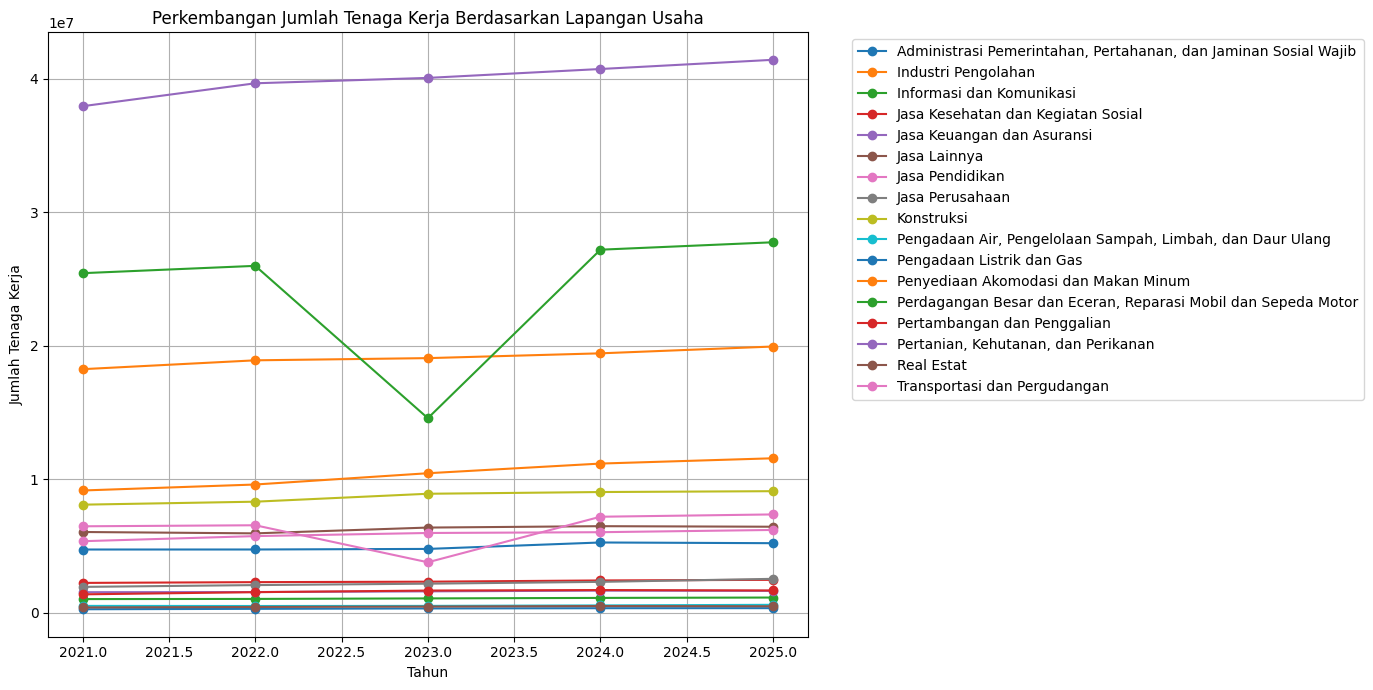

In [44]:
# Visualisasi perkembangan jumlah tenaga kerja 2021–2025

plt.figure(figsize=(14, 7))

for sektor in eda_pekerja["lapangan_usaha"].unique():
    if sektor != "Total":
        data_sektor = eda_pekerja[
            eda_pekerja["lapangan_usaha"] == sektor
        ]
        
        plt.plot(
            data_sektor["tahun"],
            data_sektor["jumlah_pekerja"],
            marker="o",
            label=sektor
        )

plt.title("Perkembangan Jumlah Tenaga Kerja Berdasarkan Lapangan Usaha")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Tenaga Kerja")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(True)
plt.tight_layout()
plt.show()

**2. Apakah tingkat pengangguran memiliki hubungan dengan jumlah tenaga kerja berdasarkan lapangan usaha di Indonesia?**

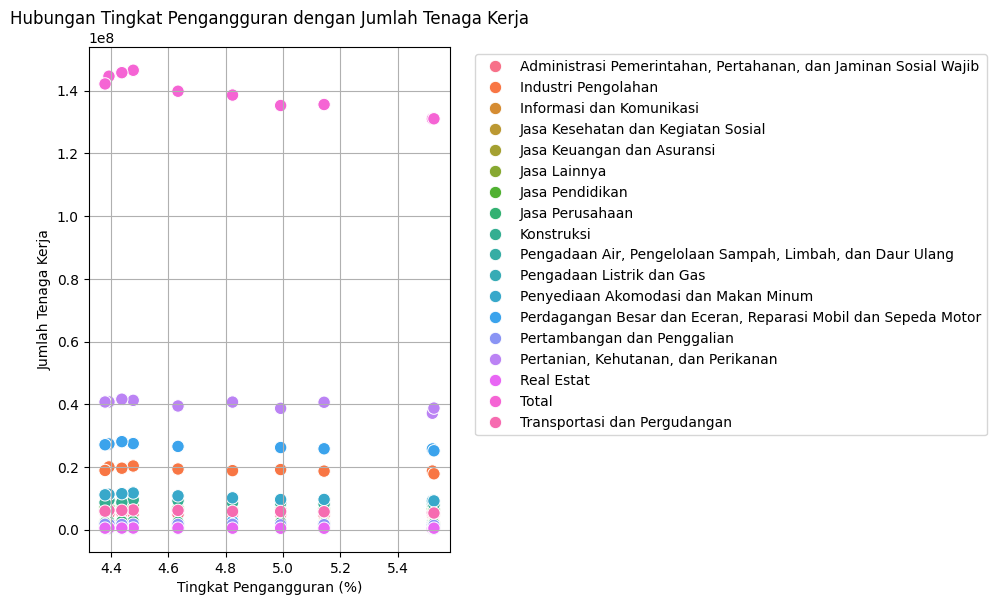

In [45]:
# Visualisasi hubungan TPT dengan jumlah tenaga kerja

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data_q2,
    x="tingkat_pengangguran",
    y="jumlah_pekerja",
    hue="lapangan_usaha",
    s=80
)

plt.title("Hubungan Tingkat Pengangguran dengan Jumlah Tenaga Kerja")
plt.xlabel("Tingkat Pengangguran (%)")
plt.ylabel("Jumlah Tenaga Kerja")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(True)
plt.tight_layout()
plt.show()

**3. Apakah konsentrasi tenaga kerja antarprovinsi memiliki hubungan dengan jumlah tenaga kerja berdasarkan lapangan usaha di Indonesia?**

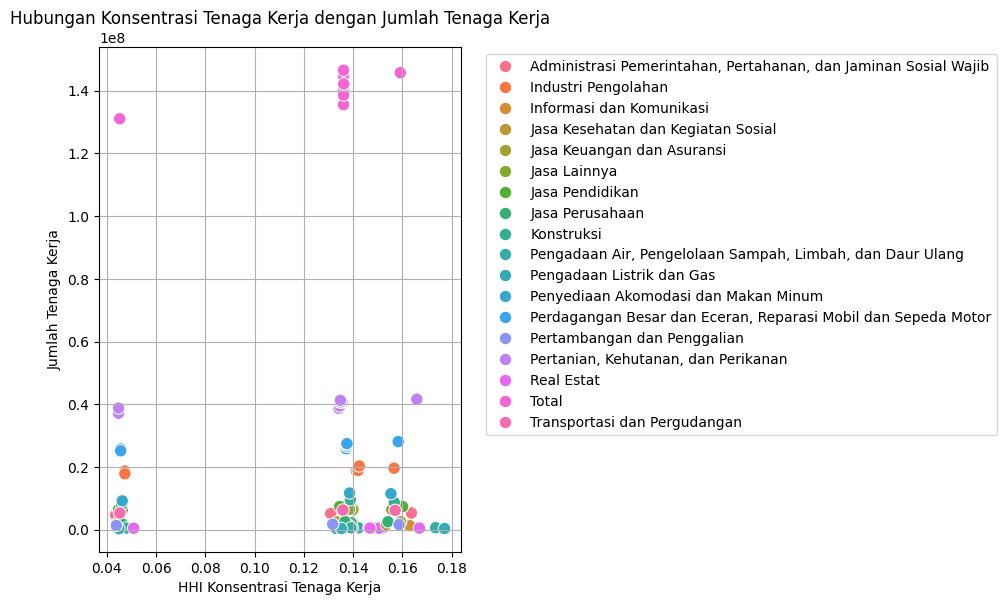

In [46]:
# Visualisasi hubungan HHI dengan jumlah tenaga kerja

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data_q3,
    x="hhi_konsentrasi",
    y="jumlah_pekerja",
    hue="lapangan_usaha",
    s=80
)

plt.title("Hubungan Konsentrasi Tenaga Kerja dengan Jumlah Tenaga Kerja")
plt.xlabel("HHI Konsentrasi Tenaga Kerja")
plt.ylabel("Jumlah Tenaga Kerja")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(True)
plt.tight_layout()
plt.show()

**4. Dapatkah tingkat pengangguran pada periode berikutnya diprediksi berdasarkan data historis tingkat pengangguran di Indonesia?**

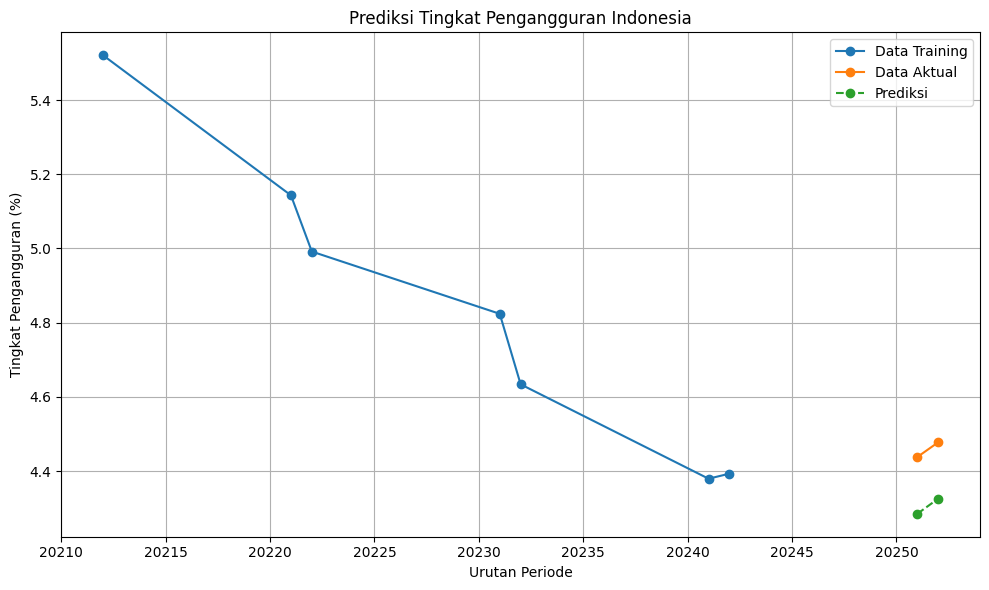

In [47]:
# Visualisasi aktual dan prediksi tingkat pengangguran

plt.figure(figsize=(10, 6))

plt.plot(
    train["urutan"],
    y_train,
    marker="o",
    label="Data Training"
)

plt.plot(
    test["urutan"],
    y_test,
    marker="o",
    label="Data Aktual"
)

plt.plot(
    test["urutan"],
    prediksi_tpt,
    marker="o",
    linestyle="--",
    label="Prediksi"
)

plt.title("Prediksi Tingkat Pengangguran Indonesia")
plt.xlabel("Urutan Periode")
plt.ylabel("Tingkat Pengangguran (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### **Insight Visualization & Exploratory Analysis**

- Visualisasi Q1 menunjukkan bahwa jumlah tenaga kerja secara umum meningkat dari 2021 hingga 2025, dengan perbedaan perkembangan pada setiap lapangan usaha.
- Visualisasi Q2 menunjukkan pola hubungan negatif antara tingkat pengangguran dan jumlah tenaga kerja pada sebagian besar lapangan usaha.
- Visualisasi Q3 menunjukkan kecenderungan hubungan positif antara konsentrasi tenaga kerja antarprovinsi (HHI) dan jumlah tenaga kerja pada sebagian besar lapangan usaha.
- Visualisasi Q4 menunjukkan bahwa hasil prediksi mengikuti arah perubahan data historis, dengan prediksi TPT periode berikutnya sebesar 4,36%.
- Secara keseluruhan, visualisasi membantu memperlihatkan pola perkembangan, hubungan antarvariabel, dan hasil prediksi yang diperoleh dari analisis.

## **Export Data**

In [50]:
# Export data untuk Streamlit

df_pekerja_bersih.to_csv(
    "streamlit_app/data/tenaga_kerja.csv",
    index=False
)

df_pengangguran_bersih.to_csv(
    "streamlit_app/data/pengangguran.csv",
    index=False
)

df_pekerja_provinsi_bersih.to_csv(
    "streamlit_app/data/pekerja_provinsi.csv",
    index=False
)

print("Data berhasil diekspor untuk Streamlit!")

Data berhasil diekspor untuk Streamlit!
